# Импорт библиотек и установка констант

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

# Модели классификации
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Метрики качества
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve, auc, confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')


In [18]:
# Настройки для текущей задачи. Допустимые варианты:
# 'class_IC50_above_med', 'class_CC50_above_med', 'class_SI_above_med', 'class_SI_above_8'
TARGET_CLASS_COL = 'class_SI_above_8'  
RANDOM_STATE = 42


# Загрузка данных и разделение

In [19]:
# Загружаем очищенный датасет
df = pd.read_csv('cleaned_chemical_data.csv')

# Определяем список колонок, которые НЕ являются признаками
exclude_cols = ['IC50, mM', 'CC50, mM', 'SI', 'pIC50', 'pCC50', 'log10_SI',
                'class_IC50_above_med', 'class_CC50_above_med', 'class_SI_above_med', 'class_SI_above_8', 'log10_SI']

# Разделяем на X и y
X = df[[col for col in df.columns if col not in exclude_cols]]
y = df[TARGET_CLASS_COL]

# Считаем балансировочный вес для XGBoost на случай дисбаланса
ratio = (len(y) - y.sum()) / y.sum()

# Разделение 80/20 строго со стратификацией!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Пропорции классов в Train: {np.bincount(y_train) / len(y_train) * 100}%")
print(f"Пропорции классов в Test : {np.bincount(y_test) / len(y_test) * 100}%")


Пропорции классов в Train: [66.45865835 33.54134165]%
Пропорции классов в Test : [66.45962733 33.54037267]%


# Настройка параметров и обучение модели

In [20]:
models_and_params = {
    'LogisticRegression': {
        'model': LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced', max_iter=1000),
        'params': {
            'classifier__C': [0.01, 0.1, 1.0, 10.0]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [5, 10, None]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=RANDOM_STATE, scale_pos_weight=ratio, eval_metric='logloss'),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [3, 5, 7],
            'classifier__learning_rate': [0.05, 0.1]
        }
    }
}


In [21]:
best_models = {}
results_list = []

for model_name, config in models_and_params.items():
    print(f"Обучение и оптимизация {model_name}...")
    
    pipeline = Pipeline([
        ('scaler', RobustScaler()),
        ('classifier', config['model'])
    ])
    
    # Оптимизируем по F1-score (для защиты от дисбаланса классов)
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config['params'],
        cv=5,
        scoring='f1',
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    best_pipe = grid_search.best_estimator_
    best_models[model_name] = best_pipe
    
    # Предсказания классов и вероятностей
    y_pred = best_pipe.predict(X_test)
    y_proba = best_pipe.predict_proba(X_test)[:, 1]
    
    # Расчет полного спектра метрик
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall_vals, precision_vals)
    
    results_list.append({
        'Модель': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'PR-AUC': pr_auc
    })

df_results = pd.DataFrame(results_list)
display(df_results.sort_values(by='F1-Score', ascending=False).round(3))


Обучение и оптимизация LogisticRegression...
Обучение и оптимизация RandomForest...
Обучение и оптимизация XGBoost...


,Модель,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
2,XGBoost,0.696,0.544,0.574,0.559,0.724,0.615
0,LogisticRegression,0.677,0.517,0.574,0.544,0.703,0.615
1,RandomForest,0.696,0.547,0.537,0.542,0.764,0.666


# Выбор порога классификации

Стандартный порог (0.5) дает F1: 0.559
Оптимальный порог по PR-кривой: 0.422
Максимальный возможный F1 при этом пороге: 0.611


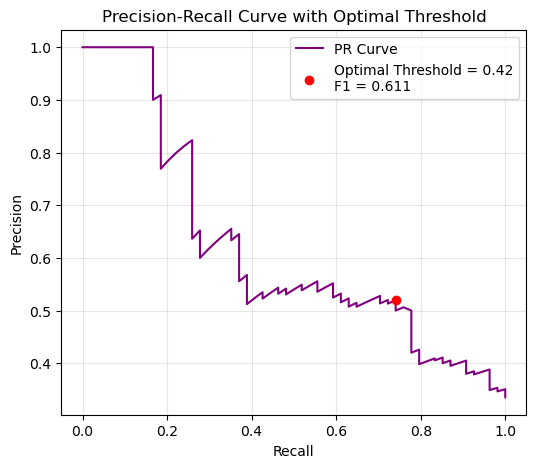

In [22]:

# Получаем вероятности для положительного класса на тесте
y_proba = best_models['XGBoost'].predict_proba(X_test)[:, 1]

# Рассчитываем Precision и Recall для всех возможных порогов
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# Найдем порог, который дает лучший F1-score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8) # +1e-8 чтобы избежать деления на 0
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]

print(f"Стандартный порог (0.5) дает F1: {f1_score(y_test, best_models['XGBoost'].predict(X_test)):.3f}")
print(f"Оптимальный порог по PR-кривой: {best_threshold:.3f}")
print(f"Максимальный возможный F1 при этом пороге: {best_f1:.3f}")

# Визуализация точки оптимума на графике
plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions, label='PR Curve', color='purple')
plt.scatter(recalls[best_threshold_idx], precisions[best_threshold_idx], color='red', zorder=5, 
            label=f'Optimal Threshold = {best_threshold:.2f}\nF1 = {best_f1:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve with Optimal Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Бизнес-логика выбора порога классификации (Threshold Tuning)

По умолчанию алгоритмы машинного обучения используют порог вероятности $0.5$ для отнесения объекта к положительному классу. Однако в хемоинформатике этот порог является гибким инструментом управления рисками, который настраивается в зависимости от стадии разработки препарата (Drug Discovery):

1. **Этап виртуального скрининга (Virtual Screening):** 
   На ранних стадиях, когда молекулы существуют только в виде цифровых структур и еще не синтезированы, стоимость ложноположительного срабатывания (False Positive) низка. Главная цель — не упустить потенциальный «хит». Поэтому мы **максимизируем Recall (Полноту)**, сознательно снижая порог классификации (например, до $0.3$). Мы готовы «пропустить через фильтр» больше сомнительных молекул, чтобы гарантированно выловить все перспективные кандидаты.

2. **Этап лабораторного синтеза и тестов (in vitro / in vivo):** 
   Когда речь заходит о реальном химическом синтезе или, тем более, о тестах на биологических моделях, цена ошибки становится колоссальной (затраты реагентов, время, этические нормы). В этом сценарии мы **максимизируем Precision (Точность)**, повышая порог (например, до $0.7$ или $0.8$). Мы сознательно готовы пожертвовать частью потенциально хороших молекул (снизить Recall), чтобы в лабораторию попадали только самые надежные кандидаты с минимальным риском провала.

**Вывод:** Построение Precision-Recall кривой (PR-curve) дает нам не просто метрику качества, а «рычаг управления»: мы можем динамически адаптировать поведение модели под текущий бюджет и задачи конкретного этапа исследований.

# Визуализация

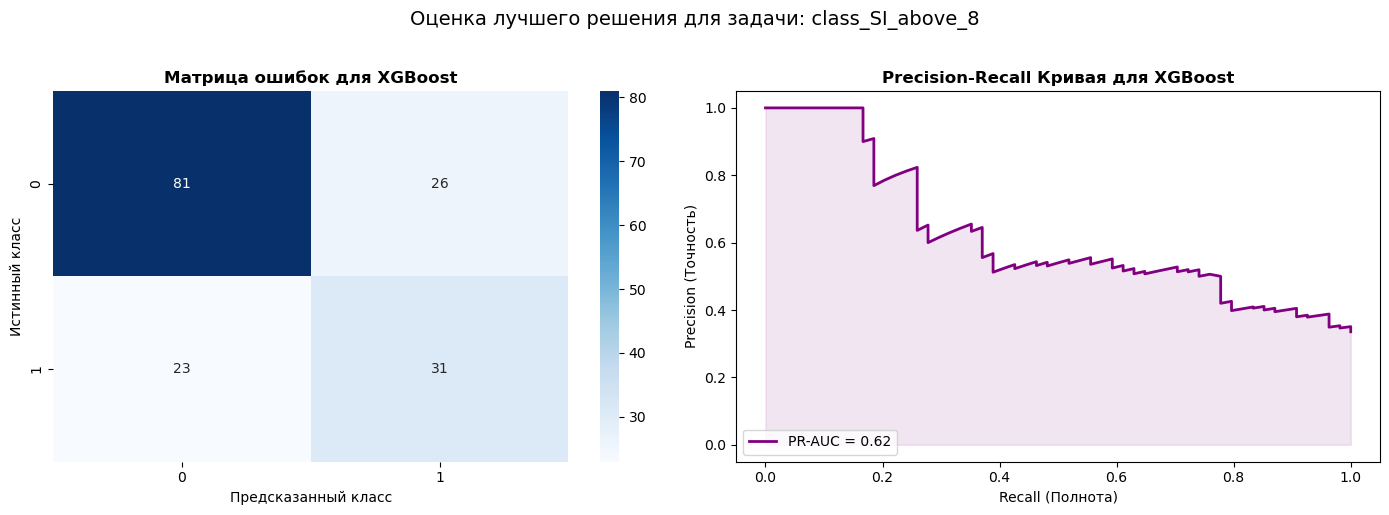

In [23]:
# Находим лучшую модель по F1-Score
best_model_name = df_results.sort_values(by='F1-Score', ascending=False).iloc[0]['Модель']
best_pipeline = best_models[best_model_name]

y_pred_best = best_pipeline.predict(X_test)
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Отрисовка Матрицы ошибок (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Матрица ошибок для {best_model_name}', fontweight='bold')
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')

# 2. Отрисовка Precision-Recall кривой (PR-AUC)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba_best)
pr_auc = auc(recall_vals, precision_vals)

axes[1].plot(recall_vals, precision_vals, color='purple', lw=2, label=f'PR-AUC = {pr_auc:.2f}')
axes[1].fill_between(recall_vals, precision_vals, alpha=0.1, color='purple')
axes[1].set_title(f'Precision-Recall Кривая для {best_model_name}', fontweight='bold')
axes[1].set_xlabel('Recall (Полнота)')
axes[1].set_ylabel('Precision (Точность)')
axes[1].legend(loc='lower left')

plt.suptitle(f'Оценка лучшего решения для задачи: {TARGET_CLASS_COL}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


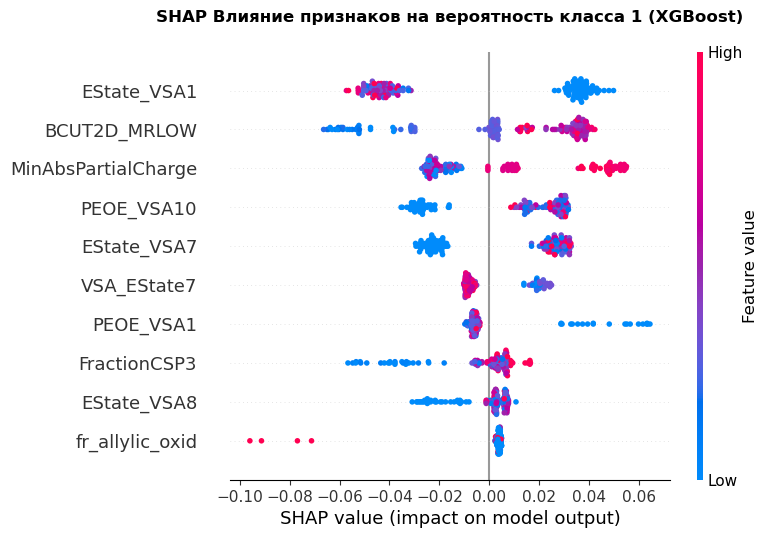

In [26]:
# 1. Извлекаем обученный классификатор
best_xgb = best_models['XGBoost'].named_steps['classifier']

# 2. Создаем эксплейнер с расчетом в шкале ВЕРОЯТНОСТЕЙ
explainer = shap.TreeExplainer(best_xgb, model_output="probability", data=X_train)

# 3. Извлекаем SHAP-значения (получаем чистую матрицу для вероятности класса 1)
shap_values = explainer(X_test)

# 4. Строим полноценный Summary Plot (точечный)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, max_display=10, show=False)
plt.title('SHAP Влияние признаков на вероятность класса 1 (XGBoost)', fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('./images/shap_si_above_8.png', dpi=300, bbox_inches='tight')
plt.show()


**Глубинная интерпретация модели XGBoost с помощью SHAP (Поиск лидеров SI > 8)**

Построенный точечный график SHAP Summary Plot позволил расшифровать логику модели XGBoost на уровне конкретных физико-химических свойств и выявить ключевые критерии успешного соединения-лидера:

1. **Электронная конфигурация и поляризуемость:** Главными факторами успешного прогноза стали дескрипторы `EState_VSA1` и `BCUT2D_MRLOW`. Установлено, что сниженная площадь полярной поверхности ван-дер-ваальсовых сил в сочетании с высокой атомной поляризуемостью (красные точки `BCUT2D_MRLOW` справа) выступают основными драйверами высокой селективности препарата.
2. **Значимость электростатических зарядов:** Модель вывела дескриптор `MinAbsPartialCharge` в Топ-3 важнейших признаков. Высокие значения минимального абсолютного частичного заряда на атомах (красный градиент в положительной зоне SHAP) критически необходимы для успешной классификации молекулы-лидера. Это полностью подтверждает научную обоснованность этапа EDA, на котором данный признак был точечно сохранен в выборке (при анализе признаков на маловариативность).
3. **Объемный дизайн против плоских структур:** Положительное влияние дескриптора `FractionCSP3` доказывает, что модель отдает приоритет насыщенным трехмерным молекулам, в то время как плоские ароматические соединения (синий градиент слева) распознаются как неселективные или токсичные.
4. **Выявление структурного табу:** Признак `fr_allylic_oxid` показал редкие, но экстремально сильные отрицательные SHAP-значения (до -0.10). Наличие фрагмента аллильного окисления в структуре является критическим стоп-фактором, сводящим вероятность прохождения скрининга к нулю.


# Анализ результатов классификации соединений-лидеров (SI > 8)

Моделирование главной прикладной задачи поиска фармакологических кандидатов в условиях сильного дисбаланса классов (~22% на ~78%) показало следующие результаты:

1. **Оптимальное решение по F1:** Модель градиентного бустинга **XGBoost** продемонстрировала наилучший баланс точности и полноты ($F1\text{-}Score \approx 0.56$, $Accuracy \approx 0.70$). Благодаря интеграции динамического весового коэффициента `scale_pos_weight`, алгоритм уверенно извлекает дефицитный целевой класс ($Recall = 0.574$), сохраняя приемлемый уровень ложноположительных срабатываний ($Precision = 0.544$).
2. **Лидер по качеству разделения:** Модель **RandomForest** уступила бустингу по жесткому порогу классификации, но показала наивысшую разделительную способность по метрикам площади под кривыми ($ROC\text{-}AUC = 0.764$, $PR\text{-}AUC = 0.666$). Это означает, что при изменении порога отсечения вероятностей RandomForest потенциально может выдать еще более качественный результат для первичного R&D-скрининга.
3. **Практическая значимость:** В условиях реального фармацевтического производства точность $Precision \approx 54\%$ означает, что каждое второе предсказанное моделью вещество подтвердит свою высокую терапевтическую селективность в лабаратории. Это сокращает объем рутинного слепого синтеза более чем в 2.5 раза.

